# 🏠😊💷💶 Keeping Up With The Jones:- Hypothesis Testings

## Objectives

* In this notebook, we shall attempt to do some hypothesis testings.

## Inputs

* ../data/processed/01c_df_regional_wellbeing_6countries_no_overseas.csv

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

## Set Up directories and Import Necessary Libraries

In [1]:
# System and OS related tasks
import sys
import os

# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

In [2]:
# Get the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg

sns.set_style('whitegrid') # sets a white background with grid lines 

In [3]:
# Get data:

filename = "01c_df_regional_wellbeing_6countries_no_overseas.csv"

df_regional_wellbeing_6countries_mainland = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

df_regional_wellbeing_6countries_mainland.head(3)

,xls_row_id,country,region,region_code,disposable_income_pc,employment_rate,unemployment_rate,homicide_rate,life_expectancy,secondary_education_pct,rooms_per_capita,mortality_rate,voter_turnout_pct,broadband_access_pct,air_quality_pm25,life_satisfaction_index,housing_affordability_pct,internet_speed_deviation,social_network_support_index,country_iso3
0,111,France,Île-de-France,FR1,35629.0,68.7,7.9,1.0,84.9,84.1,1.5,6.9,76.0,94.2,12.7,6.7,43.4,55.0,88.8,FRA
1,112,France,Centre-Val de Loire,FRB,30823.6,70.7,5.8,0.8,82.6,86.5,2.0,8.3,75.0,87.4,8.9,6.4,47.9,53.2,88.5,FRA
2,113,France,Bourgogne-Franche-Comté,FRC,30839.7,68.9,6.6,0.6,82.3,82.0,2.0,8.4,77.1,83.9,9.8,6.7,41.5,45.8,95.4,FRA


---

# 1.0 Hypothesis Testings

📌 The North-South divide is one of the most persistent stories in the British political and socioeconomic life. For decades, policymaker, journalists and the man on the street have pointed out this gap and many times, regions are embroiled in heated rivaries. This has lead to the "Levelling Up" agenda which is based on the narrative that _**"The North is poor, broken and unhappy and that the richer South should pick up the bills and perk up the North"**_. 

📌 This project aims to test the existence of said wealth gap. This project also aims to look at whether, the well-being of residents in these regions are related to their relative wealth. If based on the data that the North is indeed poor but in fact happier, then should the levelling up agenda focus on well-being or wealth? 

📌 This project then do a side step to compare the UK to 5 other neighbouring nations in Eurpore to see if indeed the UK is "keeping up with the Joneses".



📌 In this notebook, we will attempt to test the following hypotheses:

* Hypothesis 1: `MVP` _**"The North-outh Wealth Gap"**_ attempts to look at whether there is a significant difference in disposable income per capita between the Northern and Southern regions.

>
> H<sub>0</sub>: The mean disposable income per capita (US$ PPP) of Northern UK regions is equal to the mean disposable income per capita (US$ PPP) of Southern UK regions.
> 


* Hypothesis 2: `MVP` _**"The North-South Happiness Gap"**_ attempts to look at whether there is a significant difference in life satisfaaction between the Northern and Southern regions.

>
> H<sub>0</sub>: The mean life satisfaction of Northern UK regions is equal to the mean life satisfaction of Southern UK regions.
> 


 * Hypothesis 3: `MVP` _**"The North-South Health Gap"**_ attempts to look at whether there is a significant difference in life expectancy between the Northern and Southern regions.

>
> H<sub>0</sub>: The mean life expectancy of Northern UK regions is equal to the mean life expectancy of Southern UK regions.
> 


* Hypothesis 4: `MVP` _**"Keeping Up with the Joneses" Richer but Happier and Healthier?"**_ Is the relationship between income, life expectancy and life satisfaction different in the UK compared to the selected six nations

>
> H<sub>0</sub>: The correlations between income, life expectancy and life satisfaction are the same for the UK and the selected six European nations.
> 

> As this will be a long notebook, it will be sectioned as follows:
>
> * X.0 Hypothesis No 1: 
>
>   * X.1 Preparing the Data
>
>   * X.2 Data Exploration (EDA)
>        * various data visualisation plots 
>
>   * X.3 Statistical Test
>     * t-test output with p-value or chi-square test
>
>   * X.4 Result Visualisation & Conclusion
>     * various data visualisation plots 
>     * Clear statement of what the visualisation and statistical tests mean together
>

---

## 1.1 Hypothesis 1: `MVP` _**"The North-South Wealth Gap"**_

>
> H<sub>0</sub>: The mean life satisfaction of Northern UK regions is equal to the mean life satisfaction of Southern UK regions.
> 

>
> H<sub>1</sub>: The mean life satisfaction of Northern UK regions is not equal to the mean life satisfaction of Southern UK regions.
> 

### 1.1.1 Prepare the Data

In [4]:
df_uk_regions = df_regional_wellbeing_6countries_mainland[df_regional_wellbeing_6countries_mainland["country_iso3"] == "GBR"]

df_uk_regions["region"].value_counts()

region
North East England          1
North West England          1
Yorkshire and The Humber    1
East Midlands               1
West Midlands               1
East of England             1
Greater London              1
South East England          1
South West England          1
Wales                       1
Scotland                    1
Northern Ireland            1
Name: count, dtype: int64

In [5]:
# Group UK Regions into the North and South

UK_North = ["North East England", "North West England", "Yorkshire and The Humber", "Scotland", "Northern Ireland", "Wales"]

UK_South = ["East Midlands", "West Midlands", "East of England", "Greater London", "South East England", "South West England"]


In [6]:
# create a mapping function for the north south groupings
def assign_north_south(region):
    if region in UK_North:
        return "North"
    elif region in UK_South:
        return "South"
    else:
        return "Other"

In [7]:
df_regional_wellbeing_6countries_mainland["north_south"] = df_regional_wellbeing_6countries_mainland["region"].apply(assign_north_south)

In [8]:
df_regional_wellbeing_6countries_mainland["north_south"].value_counts()

north_south
Other    79
North     6
South     6
Name: count, dtype: int64

### 1.1.2 EDA on Disposal Income per Capita

In [9]:
# Get UK only wellbeing data
df_regional_wellbeing_uk = df_regional_wellbeing_6countries_mainland[df_regional_wellbeing_6countries_mainland["country_iso3"] == "GBR"]

df_regional_wellbeing_uk.value_counts()

xls_row_id  country         region                    region_code  disposable_income_pc  employment_rate  unemployment_rate  homicide_rate  life_expectancy  secondary_education_pct  rooms_per_capita  mortality_rate  voter_turnout_pct  broadband_access_pct  air_quality_pm25  life_satisfaction_index  housing_affordability_pct  internet_speed_deviation  social_network_support_index  country_iso3  north_south
387         United Kingdom  North East England        UKC          26722.4               69.0             3.8                1.1            79.2             75.6                     1.9               10.2            57.3               99.8                  8.4               7.0                      55.4                       -1.2                      89.3                          GBR           North          1
388         United Kingdom  North West England        UKD          28817.3               75.8             4.0                1.0            79.2             79.9                

In [10]:
# EDA UK northern region
northern_region_wellbeing = df_regional_wellbeing_uk[df_regional_wellbeing_uk["north_south"] == "North"]

northern_region_wellbeing["disposable_income_pc"].describe()

count        6.000000
mean     28090.266667
std       1475.123680
min      26722.400000
25%      27027.975000
50%      27709.250000
75%      28644.625000
max      30643.400000
Name: disposable_income_pc, dtype: float64

In [11]:
# EDA UK southern region
southern_region_wellbeing = df_regional_wellbeing_uk[df_regional_wellbeing_uk["north_south"] == "South"]

southern_region_wellbeing["disposable_income_pc"].describe()

count        6.000000
mean     34986.833333
std       6980.242929
min      28279.000000
25%      30037.375000
50%      33833.600000
75%      36884.250000
max      47301.700000
Name: disposable_income_pc, dtype: float64

📌 The mean income of the South (US$ 34,987) is higher than the North (US$ 28,090) with standard deviations of US$ 6,980 and US$1.475 respectively. The South is far more unequal within the group with the North beng more clustered together. This could be that London being the powerhouse in the South is pulling the mean up. 

📌 Let's test for normalcy of the disposable income

In [13]:
pg.normality(data=df_regional_wellbeing_uk['disposable_income_pc'], alpha=0.05)

,W,pval,normal
disposable_income_pc,0.775861,0.005045,False


📝 The disposable income for UK as a whole is not normally distributed.

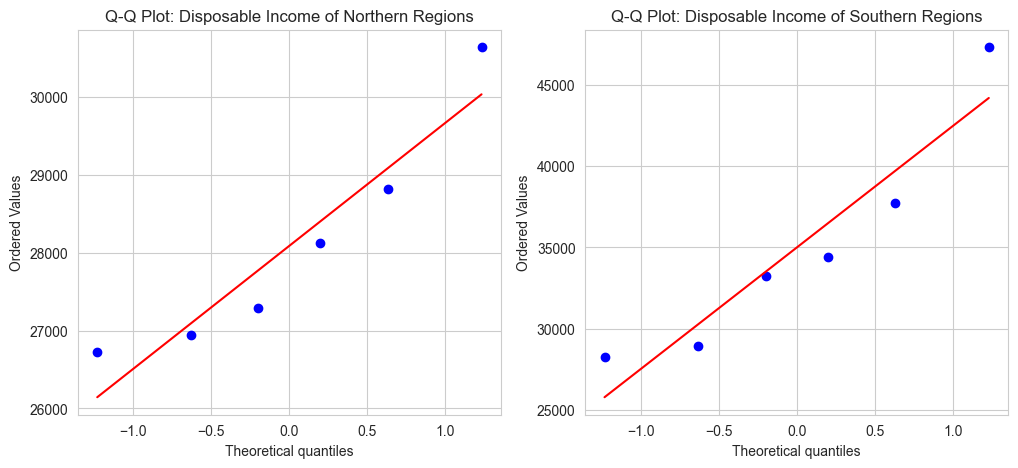

In [12]:
# Q-Q plots to check normality#
northern_income = northern_region_wellbeing["disposable_income_pc"]
southern_income = southern_region_wellbeing["disposable_income_pc"]

# do the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(northern_income, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Disposable Income of Northern Regions')
stats.probplot(southern_income, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Disposable Income of Southern Regions')
plt.show()

Looking at the distribution and box plots:

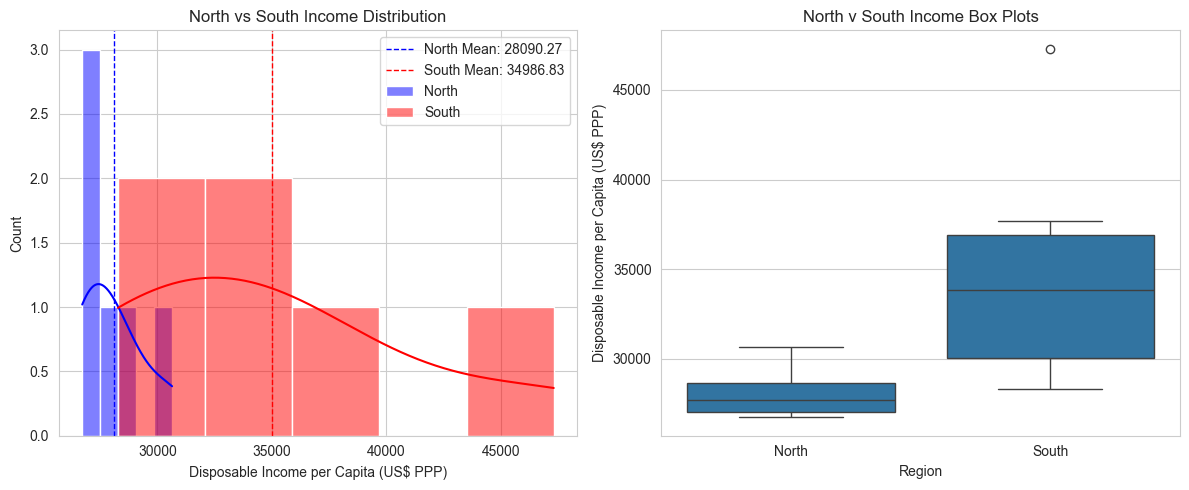

In [25]:
fig, axes = plt.subplots(nrows=1 ,ncols=2 ,figsize=(12,5))

north_mean = round(northern_region_wellbeing["disposable_income_pc"].mean(),2)
south_mean = round(southern_region_wellbeing["disposable_income_pc"].mean(),2)

# create the histogram with KDE
sns.histplot(data=northern_region_wellbeing["disposable_income_pc"]
             , kde=True, color="blue", alpha=0.5, label="North", bins=5, ax=axes[0]
             )

sns.histplot(data=southern_region_wellbeing["disposable_income_pc"]
             , kde=True, color="red", alpha=0.5, label="South", bins=5, ax=axes[0]
             )
# Add the mean lines
axes[0].axvline(north_mean
                , color='blue', linestyle='dashed', linewidth=1
                , label=f"North Mean: {north_mean}"
                )
axes[0].axvline(south_mean
                , color='red'
                , linestyle='dashed'
                , linewidth=1
                , label=f"South Mean: {south_mean}"
                )
axes[0].legend(loc="upper right")
axes[0].set(title="North vs South Income Distribution"
            , xlabel="Disposable Income per Capita (US$ PPP)"
            , ylabel="Count")


sns.boxplot(data=df_regional_wellbeing_uk
            , x="north_south"
            , y="disposable_income_pc"
            , ax=axes[1]
            , order=["North", "South"]
            )
axes[1].set(title="North v South Income Box Plots"
        , xlabel="Region"
        , ylabel="Disposable Income per Capita (US$ PPP)"
        )

plt.tight_layout()
plt.show()
print("\n\n")


In [15]:
pg.normality(data=df_regional_wellbeing_uk,dv='disposable_income_pc', group='north_south', alpha=0.05)

,W,pval,normal
north_south,,,
North,0.895706,0.349171,True
South,0.897587,0.359863,True


📝 Both the QQ plots and the normality test say that disposable income for the south and the north respectivelly follow a normal distribution. 

### 1.1.3 Statistical Tests

📌 Using the independent sample t-test, we obtained `p-val` of 0.039423 which is less than the 5% significance level (⍺ = 0.05). Therefore, we _**could**_ reject H<sub>0</sub> and conclude that there is a statistically significant difference in disposable income per capita (US$ PPP) between the north and the south of UK.

In [32]:
# Standard t-test 
h1_test_results = pg.ttest(
    southern_region_wellbeing["disposable_income_pc"]
    , northern_region_wellbeing["disposable_income_pc"]
   #, correction=True  # Welch's test which does not assume equal variance
)

print(h1_test_results)

              T  dof alternative     p_val                CI95   cohen_d  \
T_test  2.36783   10   two-sided  0.039423  [406.87, 13386.27]  1.367068   

           power   BF10  
T_test  0.570637  2.109  


📌 However, the standard deviation of the North and South disposable income is quite large at S$ 6,980 and US$1.475 respectively. 

When we use the Welch's t-test which does not assume equal variance, we obtained `p-val` of 0.059962 which is more than the 5% significance level (⍺ = 0.05). Therefore, we _**COULD NOT**_ reject H<sub>0</sub> and conclude that there is NO statistically significant difference in disposable income per capita (US$ PPP) between the north and the south of UK.

In [33]:
# Welch's t-test 
h1_test_results = pg.ttest(
    southern_region_wellbeing["disposable_income_pc"]
    , northern_region_wellbeing["disposable_income_pc"]
   , correction=True  # Welch's test which does not assume equal variance
)

print(h1_test_results)

              T       dof alternative     p_val                 CI95  \
T_test  2.36783  5.445708   two-sided  0.059962  [-409.92, 14203.06]   

         cohen_d     power   BF10  
T_test  1.367068  0.570637  2.109  


📌 However, Welch's t-test still assume that the disposable income is normally distributed but with a small observations of 6 in each region perhaps the Mann-Whitney's U test is more suitable as it does not assume normal distribution nor does it assume equal variance?

When we use the Mann-Whitney's U test, we obtained `p-val` of 0.015152 which is more than the 5% significance level (⍺ = 0.05). Therefore, we _**COULD**_ reject H<sub>0</sub> and conclude that there is a statistically significant difference in disposable income per capita (US$ PPP) between the north and the south of UK.

In [34]:
pg.mwu(
    x=southern_region_wellbeing["disposable_income_pc"]
    , y=northern_region_wellbeing["disposable_income_pc"]
    ) 

,U_val,alternative,p_val,RBC,CLES
MWU,33.0,two-sided,0.015152,0.833333,0.916667


### 1.1.4 Conclusion

>
> _**🕵🏻‍♂️🔍 Using the results of the Mann-Whitney's U test, with ⍺ = 0.05 and since p = 0.015152, we reject H<sub>0</sub> and conclude that there is a statistically significant difference in disposable income per capita (US$ PPP) between the north and the south of UK.**_
>

📌 Limitations and Justifications:
* Whilst the total number of observations is only 12, we are testing all the UK regions at TL2 level. This is a complete population and not a sample. 
  * However, at the TL2 aggregation levels, the small number of observations makes the testing very sensitive to outliers and could therefore skew the results.
* The Shapiro-Wiulk test indicated that both the Northern and Southern disposable income follow a normal distribution.
  * However, both groups showed a markedly different std deviations with the South's early 5 times that of the North.
* Whilst the Welch's t-tes is designed for unequal variances, the very small sample size of 6 in each region makes this parametric test less reliable since the results could easily be distorted by a single member of either region.


* Given these limitation, we used the Mann-Whitney U test instead as it makes no assumption about normality nor equal variance is more robust with small observations.
  * This test confirmed that the North-South wealth gap is real and not just due to random chance. With the `CLES` of 0.92, there is a 92% chance that the southern region has a higher income than the northern region. 

---

## 1.2 Hypothesis 1: `MVP` _**"The North-South Happiness Gap"**_

For this hypothesis, we will use the well-being indicator `Life_Satisfaction_Index` as a proxy for the level of happiness of the residents in these regions.

This index has a range of 0 - 10 with 10 being the most satisfied with life.

>
> H<sub>0</sub>: The mean life satisfaction of Northern UK regions is equal to the mean life satisfaction of Southern UK regions.
> 

>
> H<sub>1</sub>: The mean life satisfaction of Northern UK regions is not equal to the mean life satisfaction of Southern UK regions.
> 

### 1.2.1 Prepare the Data

We will use the dataframes created above:
* df_regional_wellbeing_uk
* northern_region_wellbeing
* southern_region_wellbeing

### 1.2.2 EDA of Life Satisfaction Index

In [36]:
# EDA UK northern region
northern_region_wellbeing["life_satisfaction_index"].describe()

count    6.000000
mean     6.833333
std      0.150555
min      6.600000
25%      6.750000
50%      6.900000
75%      6.900000
max      7.000000
Name: life_satisfaction_index, dtype: float64

In [35]:
# EDA UK southern region
southern_region_wellbeing["life_satisfaction_index"].describe()

count    6.000000
mean     6.850000
std      0.083666
min      6.700000
25%      6.825000
50%      6.900000
75%      6.900000
max      6.900000
Name: life_satisfaction_index, dtype: float64

📌 The descriptive statistics on `Life Satisfaction Index` reveal:
* The mean life statisfaction index of the South (6.85) is approximately the same as the North (6.83) with standard deviations of 0.08 and 0.15 respectively. 
* The North is twice as unequal within the group with the South being more clustered together. 
* The least happy Northern region (6.6) is a little less happy than the South (6.7)
* Again, the happiest North region (7.0) is a little happier than the South (6.9)

Despite having less disposable income (see hypothesis 1), the North appear to be just as happy as the South. However, within the North, the regions are more varied in terms of happiness.

### 1.2.3 Statistical Test on Life Satisfaction Index

📌 Having learnt from the normalcy tests in Hypothesis 1, we are going to use non-parametric test on `life_satisfaction_index` as it does not assume normalcy and would be more suitable for small number of observations than the t-tests.

In [38]:
pg.mwu(
    x=southern_region_wellbeing["life_satisfaction_index"]
    , y=northern_region_wellbeing["life_satisfaction_index"]
    ) 

,U_val,alternative,p_val,RBC,CLES
MWU,17.5,two-sided,1.0,-0.027778,0.486111


📌 With a `p-val` of 1.0, we can conclude that there is absolutely no evidence of a difference in life satisfaction index between the north and the south. And with a `CLES` of 0.486, the test says that there is 50% chance of a northern region having higher happiess than the south which is essentially as random as a coin flip.

### 1.2.4 Conclusion

>
> _**🕵🏻‍♂️🔍 Using the results of the Mann-Whitney's U test, with ⍺ = 0.05 and since p = 1.0, we do not reject H<sub>0</sub> and conclude that the mean life satisfaction of Northern UK regions is equal to the mean life satisfaction of Southern UK regions.**_
>

---

## 1.3 Hypothesis 3: `MVP` _**"The North-South Health Gap"**_

For this hypothesis, we will use the well-being indicator `life_expectancy` (in years) as a proxy for the level of health of the residents in these regions.

The assumption here is that living longer equates to be healthier.

>
> H<sub>0</sub>: The mean life expectancy of Northern UK regions is equal to the mean life satisfaction of Southern UK regions.
> 

>
> H<sub>1</sub>: The mean life expectancy of Northern UK regions is not equal to the mean life satisfaction of Southern UK regions.
> 

### 1.3.1 Prepare the Data

We will use the dataframes created above:
* df_regional_wellbeing_uk
* northern_region_wellbeing
* southern_region_wellbeing

### 1.3.2 EDA of Life Expectancy

In [40]:
# EDA UK northern region
northern_region_wellbeing["life_expectancy"].describe()

count     6.00000
mean     79.65000
std       0.49295
min      79.20000
25%      79.22500
50%      79.60000
75%      79.90000
max      80.40000
Name: life_expectancy, dtype: float64

In [41]:
# EDA UK southern region
southern_region_wellbeing["life_expectancy"].describe()

count     6.000000
mean     81.216667
std       0.803534
min      80.000000
25%      80.700000
50%      81.450000
75%      81.825000
max      82.000000
Name: life_expectancy, dtype: float64

📌 The descriptive statistics on `Life Expectancy` reveal:
* The mean life expectancy of the South (81.22 years) is a little higher than the North (79.65) with standard deviations of 0.8 and 0.5 respectively. 
    * The south lives on average 1.6 years longer than the north.
    * The south has more variation in life expectancy with some regions living longer than others.
* The least healthy northern region (79.2 years) lives 0.8 years less than the least Southern region (80 years)
* The healthiest southern region (82 years) lives 1.6 years more than the healthiest northern region (80.4 years)

📌 Despite having less disposable income (see Hypothesis 1), the North appear to be just as happy as the South (see Hypothesis 2). Howwever, it appears that the north is less healthy than the South. 

📌 On the surface, there appears to be a health gap between the north and the south. The healthiest Northern region of 80.4 years still falls below the Southern mean life expectancy of 81.2 years.

🕵🏻‍♂️🔍 So far the combinations of the descriptive statistics is interesting:
* The north faces material disadvantages because of lower disposable income (hypothesis 1) but reports a similar level of subject well being (Hypothesis 2).
* Whether this reflects resilence or simply that money and health matter less to happiness than commonly assumed is an area worth further probing.


### 1.3.3 Statistical Test on Life Expectancy

📌 Having learnt from the normalcy tests in Hypothesis 1, we are going to use non-parametric test on `life_expectancy` as it does not assume normalcy and would be more suitable for small number of observations than the t-tests.

In [42]:
pg.mwu(
    x=southern_region_wellbeing["life_expectancy"]
    , y=northern_region_wellbeing["life_expectancy"]
    ) 

,U_val,alternative,p_val,RBC,CLES
MWU,35.0,two-sided,0.008016,0.944444,0.972222


📌 With a `p-val` of 0.008, we can conclude that there is statistical evidence of a difference in mean life expectancy between the north and the south. And with a `CLES` of 0.9722, the test says that there is 97.2% chance of a Southern region having a longer life expectancy than the north.

### 1.3.4 Conclusion

>
> _**🕵🏻‍♂️🔍 Using the results of the Mann-Whitney's U test, with ⍺ = 0.05 and since `p-val` = 0.008, we reject H<sub>0</sub> and conclude that there is a statistically significant difference in mean life expectancy between the north and the south of UK.**_
>

## 1.4 Summary Conclusion for all the Hypothesis Testings for the UK Regions

| Hypothesis | Finding | CLES for South|
|---|---|---|
| H1 Wealth | North is poorer (p=0.015) | 91.2 %|
| H2 Happiness | No Difference (p=1.0) | 48.6 %|
| H3 Health | North is less healthy (p=0.008) | 97.2 %|

>
> _**🕵🏻‍♂️🔍 Whilst the UK's Northern regions are pooer and less healthy, the residents are just as happy as the neigbours in the South.**_
>

---

## 1.6 Hypothesis 4: `MVP` _**"Keeping Up with the Joneses" Richer but Happier and Healthier?"**_

For this hypothesis, we are looking at whether the relationship between income, life expectancy and life satisfaction differ between the UK and the selected five nations.

>
> H<sub>0</sub>: The correlations between income, life expectancy and life satisfaction are the same for the UK and the selected six European nations.
> 
>
> H<sub>0</sub>: The correlations between income, life expectancy and life satisfaction are not the same for the UK and the selected six European nations.
> 

This hypothesis is a slightly complicated one as we are effectively look at the relationship pairs that exist in the UK and the selected five European nations:
* Income vs life expectancy
  * In the UK, higher income South appears to have led a healthier life.
  * Is this link stronger in the UK or Europe?
* income vs life satisfaction
  * In the UK, higher income South appears to be just as happy as the North.
  * Is this the same as in the UK or Europe?
* life satisfaction vs life expectancy
  * In the UK, happiness does not appear to have an impact on health.
  * Is this the same as in the UK or Europe?


### 1.6.1 Compute the Correlations on the Indicator Pairs

In [48]:
# split the data into 2 groups UK vs Europe
df_uk = df_regional_wellbeing_6countries_mainland[df_regional_wellbeing_6countries_mainland["country_iso3"] == "GBR"]
df_eu = df_regional_wellbeing_6countries_mainland[df_regional_wellbeing_6countries_mainland["country_iso3"] != "GBR"]

print(f"The value counts of df_uk: {df_uk["country"].value_counts()}")
print("=" *50)
print(f"The value counts of df_eu: {df_eu["country"].value_counts()}")
print(f"The number of regions in the EU's 5 Nations: {len(df_eu)}")

The value counts of df_uk: country
United Kingdom    12
Name: count, dtype: int64
The value counts of df_eu: country
Italy          21
Spain          17
Germany        16
France         13
Netherlands    12
Name: count, dtype: int64
The number of regions in the EU's 5 Nations: 79


📌 Create a relationship mapping lists

In [50]:
# relationship mapping and mapping name

## Income vs Happiness
r1 = ("disposable_income_pc", "life_satisfaction_index", "Income vs Life Satisfaction")
## Income vs Health
r2 = ("disposable_income_pc", "life_expectancy", "Income vs Life Expectancy")
## happiness vs Health
r3 = ("life_satisfaction_index", "life_expectancy", "Life Satisfaction vs Life Expectancy")

all_relations = [r1, r2, r3]

📌 Compute the Correlations

In [52]:
# create an empty list to store the results of correlation computations
results_list =[]

for x, y, rname in all_relations:
    
    # compute the correlation for uk
    r_uk = round(df_uk[x].corr(df_uk[y]),3)

    # compute the correlation for eu
    r_eu = round(df_eu[x].corr(df_eu[y]),3)

    uk_eu_diff = round(abs(r_uk - r_eu), 3)

    if uk_eu_diff < 0.2:
        pattern = "Similar"
    else:
        pattern = "Different"

    # store the results
    results_list.append({
        "Relationship": rname
        , "UK-R": r_uk
        , "EU-R": r_eu
        , "Difference": uk_eu_diff 
        , "Pattern": pattern
    })


df_corr_results = pd.DataFrame(results_list)

df_corr_results


,Relationship,UK-R,EU-R,Difference,Pattern
0,Income vs Life Satisfaction,0.179,0.385,0.206,Different
1,Income vs Life Expectancy,0.659,-0.078,0.737,Different
2,Life Satisfaction vs Life Expectancy,-0.118,-0.344,0.226,Different


### 1.6.2 Conclusion

🕵🏻‍♂️🔍 Hypothesis 4 e

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [14]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)